In [1]:
import pandas as pd

#df = pd.read_parquet("../outputs/user_anomaly_scores.parquet")
# Comment out for comparison purposes
df = pd.read_parquet("../outputs/user_anomaly_scores_winner.parquet")

df.head()

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,rpzflRzythpFuQiKHWKGag,1.0,0.0,1.0,1,0.000641,1560.0,4.0,3.254877e+10,1,1
1,smQhOdnsYN96ITLdbPOTbA,1.0,0.0,1.0,1,0.000641,1561.0,3.0,2.722901e+10,1,2
2,MYakkZ8n0YI_v6WPl1RIew,1.0,0.0,1.0,1,0.000433,2309.0,4.0,2.533897e+10,1,3
3,Y4-mpc9QSPmQDnxARbABxw,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,4
4,5IANzAtEELywIEKgD1isDA,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,5


In [2]:
# Showing which is an anomaly
df[df["is_anomaly"] == 1].head(20)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,rpzflRzythpFuQiKHWKGag,1.0,0.0,1.0,1,0.000641,1560.0,4.0,3.254877e+10,1,1
1,smQhOdnsYN96ITLdbPOTbA,1.0,0.0,1.0,1,0.000641,1561.0,3.0,2.722901e+10,1,2
2,MYakkZ8n0YI_v6WPl1RIew,1.0,0.0,1.0,1,0.000433,2309.0,4.0,2.533897e+10,1,3
3,Y4-mpc9QSPmQDnxARbABxw,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,4
4,5IANzAtEELywIEKgD1isDA,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,5
5,su7UCnrdmtb12Ns-Mzc1sw,1.0,0.0,1.0,1,0.000638,1567.0,3.0,2.502480e+10,1,6
6,UFDWkuidG_le3oucvexJTw,1.0,0.0,1.0,1,0.000383,2610.0,3.0,2.361022e+10,1,7
7,r9n9LZ4m6TgKJuw0IGVDHg,1.0,0.0,1.0,1,0.000379,2639.0,3.0,2.349368e+10,1,8
8,kWjoeo5jpFJS9ZOZtpfjBQ,5.0,1.0,0.0,1,0.000418,2392.0,3.0,2.324605e+10,1,9
9,t_RCJ7K-iTziz91F27bu0A,5.0,1.0,0.0,1,0.000439,2277.0,3.0,2.287035e+10,1,10


In [3]:
df[df["is_anomaly"] == 1][[
    "avg_stars_given",
    "pct_5_star_reviews",
    "review_count",
    "reviews_per_day",
    "num_friends"
]].describe()

,avg_stars_given,pct_5_star_reviews,review_count,reviews_per_day,num_friends
count,72300.000000,72300.000000,72300.000000,72300.000000,72300.000000
mean,3.991133,0.645167,6.978548,0.001754,27.544993
std,1.524909,0.442383,28.172502,0.005966,172.369950
min,1.000000,0.000000,1.000000,0.000127,0.000000
25%,3.777778,0.000000,1.000000,0.000255,0.000000
50%,5.000000,1.000000,1.000000,0.000398,0.000000
75%,5.000000,1.000000,2.000000,0.000664,1.000000
max,5.000000,1.000000,1704.000000,0.269386,14995.000000


In [4]:
import pandas as pd
from pathlib import Path

# Load Phase 2 results (winner sweep output)
PROJECT_ROOT = Path.cwd().parent
ANOMALY_PATH = PROJECT_ROOT / "outputs" / "user_anomaly_scores_winner.parquet"

df = pd.read_parquet(ANOMALY_PATH)

top_anomalies = (
    df[df["is_anomaly"] == 1]
    .sort_values("anomaly_score", ascending=False)
)
# Find users with 0 friends who are in anomaly list
# bots
bots = top_anomalies[
    (top_anomalies['num_friends'] == 0) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

# Find "Review Bombers" 
# (Using 0.1 instead of 1.0 based on max of 0.269)
bombers = top_anomalies[
    (top_anomalies['reviews_per_day'] > 0.1) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

print("0 Friends + Anomalous (bots)")
display(bots)

print("\n High Velocity + Anomalous (Review Bombers)")
display(bombers)

0 Friends + Anomalous (bots)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
266,eTeeZ6FYFVUjEb-ZcAyE4Q,1.0,0.0,1.0,3,0.001642,1827.0,0.0,1.445172e+10,1,267
345,IksvvNqwfraapr7KnQ7Uow,5.0,1.0,0.0,3,0.001922,1561.0,0.0,1.349050e+10,1,346
481,wEQt8MxU-7sOCLJ82uvd3g,4.0,0.0,0.0,1,0.000524,1910.0,0.0,1.196267e+10,1,482
482,PqfektduSJ_Zv232ad6dAw,4.0,0.0,0.0,1,0.000524,1910.0,0.0,1.196267e+10,1,483
499,KL231hiCf16d6D4hk3PowA,1.0,0.0,1.0,3,0.001250,2400.0,0.0,1.181086e+10,1,500
543,eMw4rF48hlmrADZRMKYMJQ,4.0,0.0,0.0,1,0.000512,1953.0,0.0,1.142610e+10,1,544
544,NCUawL92V4_1tGkP64QyLw,4.0,0.0,0.0,1,0.000512,1953.0,0.0,1.142610e+10,1,545
563,Mhd3McSlneUTjkSS6xPDZg,1.0,0.0,1.0,3,0.000891,3367.0,0.0,1.125568e+10,1,564
594,zaSN2FVePb4BJ-f03hKvEg,5.0,1.0,0.0,3,0.001714,1750.0,0.0,1.102488e+10,1,596
595,WTibDP57EkpPUYARhvs-TQ,5.0,1.0,0.0,3,0.001714,1750.0,0.0,1.102488e+10,1,595



 High Velocity + Anomalous (Review Bombers)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
56635,vmUqcqMjlWoBM6qfmUXgyQ,4.586630,0.626194,0.004093,733,0.269386,2721.0,137.0,7.051641,1,56636
56644,A9cXP_K95FRor1qxuUEu2g,3.647558,0.148620,0.012739,471,0.109586,4298.0,1173.0,5.005444,1,56645
56660,wXdbkFZsfDR7utJvbWElyA,4.173807,0.291310,0.000000,817,0.226065,3614.0,727.0,4.472315,1,56661
56661,-G7Zkl1wIWBBmD0KRy_sCw,3.589823,0.147263,0.017733,1297,0.265888,4878.0,1787.0,4.437792,1,56662
56678,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,4.022643,1,56679
56706,qzquNJ5YJiidnry19rdN0w,3.932143,0.160714,0.014286,280,0.110891,2525.0,2.0,3.724202,1,56707
56709,GfI-d9mQePFA2PvhAd4WGQ,3.625413,0.242574,0.046205,606,0.149778,4046.0,706.0,3.695394,1,56710
56725,fr1Hz2acAb3OaL3l6DyKNg,3.954710,0.214674,0.002717,1104,0.252747,4368.0,825.0,3.607484,1,56726
56921,vFd8aBLg1kFcd0kCkoi-xw,4.299820,0.509874,0.019749,557,0.145545,3827.0,148.0,3.131771,1,56922
57063,-dgC1iRp_JqBTmn5d1wRhg,3.951567,0.310541,0.014245,351,0.103144,3403.0,243.0,2.964697,1,57064


In [5]:
# all anomalies Check
anomalies = df[df["is_anomaly"] == 1]

print("all anomalies:", len(anomalies))
print("zero-friend anomalies (all):", ((anomalies["num_friends"] == 0)).sum())

# top 500 anomalies only
top_anomalies = anomalies.sort_values("anomaly_score", ascending=False).head(500)
print("zero-friend anomalies (top 500):", ((top_anomalies["num_friends"] == 0)).sum())

all anomalies: 72300
zero-friend anomalies (all): 36224
zero-friend anomalies (top 500): 5


In [6]:
# Calculate correlation between all numeric columns
correlation_matrix = df[["anomaly_score", "num_friends", "reviews_per_day", "review_count"]].corr()

# Specifically look at the relationship with anomaly_score
print("Correlation with Anomaly Score:")
print(correlation_matrix["anomaly_score"].sort_values(ascending=False))

Correlation with Anomaly Score:
anomaly_score      1.000000
reviews_per_day   -0.030965
review_count      -0.031780
num_friends       -0.057559
Name: anomaly_score, dtype: float64


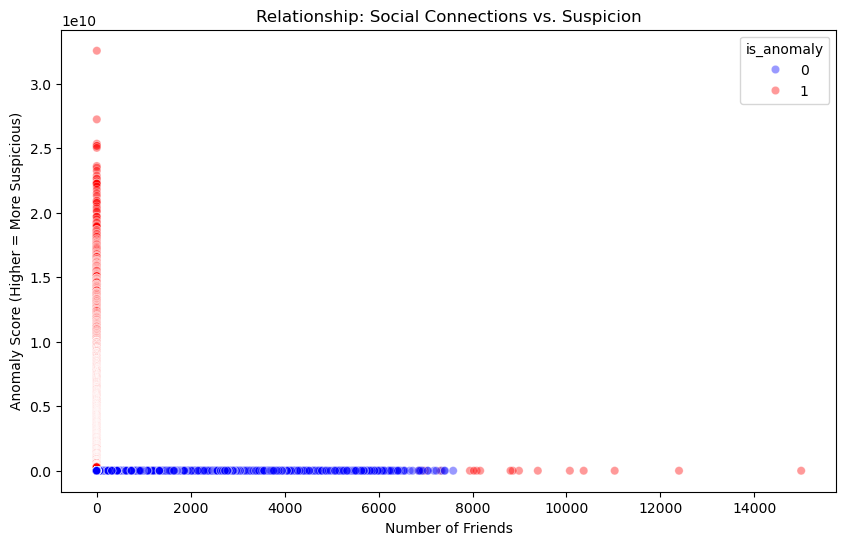

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use a scatter plot to see where the anomalies (red) sit compared to normal users (blue)
sns.scatterplot(
    data=df, 
    x="num_friends", 
    y="anomaly_score", 
    hue="is_anomaly", 
    palette={0: "blue", 1: "red"},
    alpha=0.4
)

plt.title("Relationship: Social Connections vs. Suspicion")
plt.xlabel("Number of Friends")
plt.ylabel("Anomaly Score (Higher = More Suspicious)")
plt.show()

In [8]:
# Filter only for the anomalies identified by your model
anomalies_only = df[df["is_anomaly"] == 1]

# 1. High-rating anomalous users
high_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] >= 4.5]
    .sort_values("anomaly_score", ascending=False)
)

# 2. Low-rating anomalous users
low_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] <= 1.5]
    .sort_values("anomaly_score", ascending=False)
)

print(f"Found {len(high_rating_anomalies)} high-rating anomalous users")
print(f"Found {len(low_rating_anomalies)} low-rating anomalous users")

# Display a preview for case_studies.md
print("\n--- HIGH-RATING ANOMALOUS USERS PREVIEW ---")
display(
    high_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

print("\n--- LOW-RATING ANOMALOUS USERS PREVIEW ---")
display(
    low_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

Found 44066 high-rating anomalous users
Found 13575 low-rating anomalous users

--- HIGH-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
8,kWjoeo5jpFJS9ZOZtpfjBQ,5.0,0.000418,3.0
9,t_RCJ7K-iTziz91F27bu0A,5.0,0.000439,3.0
13,eQGJ_T38I2OyxzzHa7F_sQ,5.0,0.000440,3.0
17,_NV9T5OfrCLvWMS5A2rYSw,5.0,0.000418,3.0
18,vd2Ekwc0UeEau5FD4BSrTw,5.0,0.000543,3.0



--- LOW-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
0,rpzflRzythpFuQiKHWKGag,1.0,0.000641,4.0
1,smQhOdnsYN96ITLdbPOTbA,1.0,0.000641,3.0
2,MYakkZ8n0YI_v6WPl1RIew,1.0,0.000433,4.0
3,Y4-mpc9QSPmQDnxARbABxw,1.0,0.000403,4.0
4,5IANzAtEELywIEKgD1isDA,1.0,0.000403,4.0


In [9]:
# If reviews aren't loaded, need to load them:
# reviews_df = pd.read_parquet("../data/raw/reviews.parquet")

# 1. Get the list of IDs for your top 100 anomalies
top_anomaly_ids = top_anomalies['user_id'].head(100).tolist()

# 2. Filter reviews to see which businesses were reviewed by these specific users
# target_businesses = reviews_df[reviews_df['user_id'].isin(top_anomaly_ids)]

# 3. Find businesses with the most "Anomalous" reviews
# suspicious_biz = target_businesses.groupby('business_id').size().sort_values(ascending=False)
# print("Businesses with the most hits from anomalous users:")
# print(suspicious_biz.head(10))

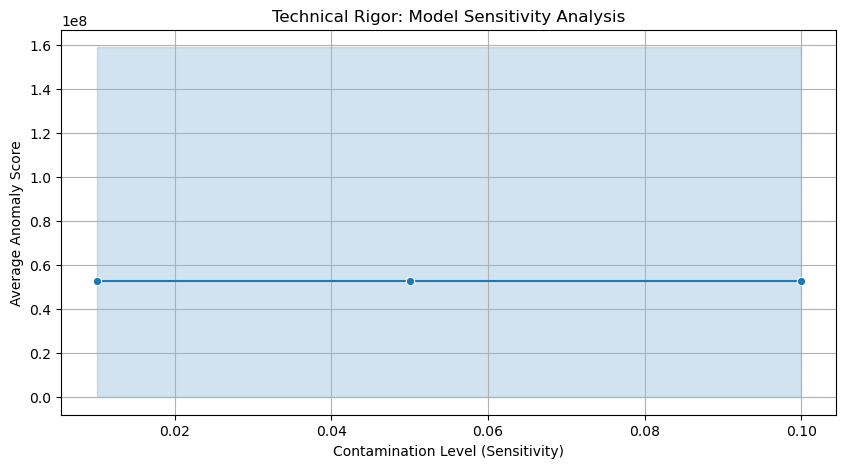

,config_name,contamination,n_anomalies,anomaly_rate
0,lof_c001,0.01,14387,0.00995
1,lof_c005,0.05,72300,0.05000
2,lof_c010,0.10,144599,0.10000
3,v1_c001_mf07,0.01,14460,0.01000
4,v1_c001_mf10,0.01,14460,0.01000
5,v1_c005_mf07,0.05,72300,0.05000
6,v1_c005_mf10,0.05,72300,0.05000
7,v1_c010_mf07,0.10,144599,0.10000
8,v1_c010_mf10,0.10,144599,0.10000


In [10]:
# Load the summary of your experiments
runs_df = pd.read_parquet("../outputs/user_anomaly_model_runs.parquet")

# Visualize the trade-off between Contamination and the Anomaly Score Mean
plt.figure(figsize=(10, 5))
sns.lineplot(data=runs_df, x="contamination", y="anomaly_score_mean", marker="o")
plt.title("Technical Rigor: Model Sensitivity Analysis")
plt.xlabel("Contamination Level (Sensitivity)")
plt.ylabel("Average Anomaly Score")
plt.grid(True)
plt.show()

display(runs_df[["config_name", "contamination", "n_anomalies", "anomaly_rate"]])

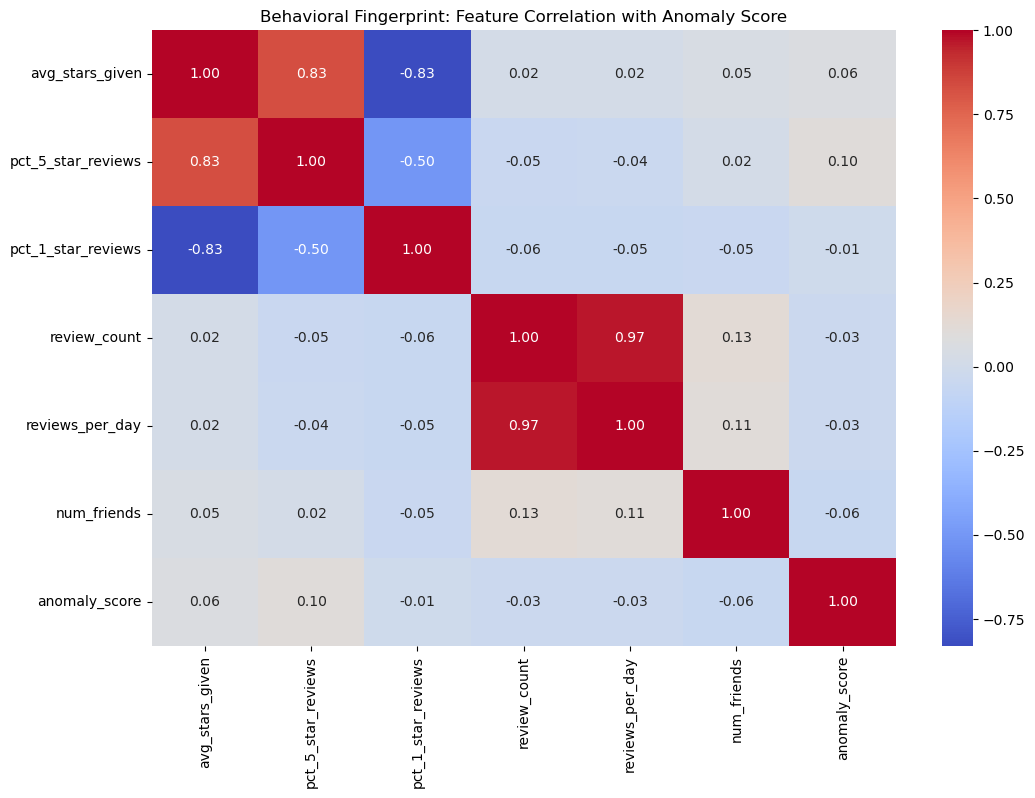

In [11]:
# Features used in your model
features = ["avg_stars_given", "pct_5_star_reviews", "pct_1_star_reviews", 
            "review_count", "reviews_per_day", "num_friends", "anomaly_score"]

plt.figure(figsize=(12, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Behavioral Fingerprint: Feature Correlation with Anomaly Score")
plt.show()

In [12]:
#  top 5 users ranked as most anomalous, along with key behavioral features
df[df["anomaly_rank"] <= 5][["user_id", "review_count", "reviews_per_day", "num_friends", "anomaly_score"]]

,user_id,review_count,reviews_per_day,num_friends,anomaly_score
0,rpzflRzythpFuQiKHWKGag,1,0.000641,4.0,3.254877e+10
1,smQhOdnsYN96ITLdbPOTbA,1,0.000641,3.0,2.722901e+10
2,MYakkZ8n0YI_v6WPl1RIew,1,0.000433,4.0,2.533897e+10
3,Y4-mpc9QSPmQDnxARbABxw,1,0.000403,4.0,2.518151e+10
4,5IANzAtEELywIEKgD1isDA,1,0.000403,4.0,2.518151e+10


In [13]:
# Looking for extreme suspicious behavior
# Finds users who: are flagged as anomalies AND give almost all 5-star OR all 1-star reviews
suspicious_extreme = df[
    (df["is_anomaly"] == 1) &
    (
        (df["pct_5_star_reviews"] > 0.95) |
        (df["pct_1_star_reviews"] > 0.95)
    )
]

suspicious_extreme = suspicious_extreme.sort_values("anomaly_score", ascending=False)
suspicious_extreme.head(10)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,rpzflRzythpFuQiKHWKGag,1.0,0.0,1.0,1,0.000641,1560.0,4.0,3.254877e+10,1,1
1,smQhOdnsYN96ITLdbPOTbA,1.0,0.0,1.0,1,0.000641,1561.0,3.0,2.722901e+10,1,2
2,MYakkZ8n0YI_v6WPl1RIew,1.0,0.0,1.0,1,0.000433,2309.0,4.0,2.533897e+10,1,3
4,5IANzAtEELywIEKgD1isDA,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,5
3,Y4-mpc9QSPmQDnxARbABxw,1.0,0.0,1.0,1,0.000403,2484.0,4.0,2.518151e+10,1,4
5,su7UCnrdmtb12Ns-Mzc1sw,1.0,0.0,1.0,1,0.000638,1567.0,3.0,2.502480e+10,1,6
6,UFDWkuidG_le3oucvexJTw,1.0,0.0,1.0,1,0.000383,2610.0,3.0,2.361022e+10,1,7
7,r9n9LZ4m6TgKJuw0IGVDHg,1.0,0.0,1.0,1,0.000379,2639.0,3.0,2.349368e+10,1,8
8,kWjoeo5jpFJS9ZOZtpfjBQ,5.0,1.0,0.0,1,0.000418,2392.0,3.0,2.324605e+10,1,9
9,t_RCJ7K-iTziz91F27bu0A,5.0,1.0,0.0,1,0.000439,2277.0,3.0,2.287035e+10,1,10


In [14]:
suspicious_extreme[
    ["user_id", "avg_stars_given", "reviews_per_day", "review_count", "num_friends"]
].head(10)

,user_id,avg_stars_given,reviews_per_day,review_count,num_friends
0,rpzflRzythpFuQiKHWKGag,1.0,0.000641,1,4.0
1,smQhOdnsYN96ITLdbPOTbA,1.0,0.000641,1,3.0
2,MYakkZ8n0YI_v6WPl1RIew,1.0,0.000433,1,4.0
4,5IANzAtEELywIEKgD1isDA,1.0,0.000403,1,4.0
3,Y4-mpc9QSPmQDnxARbABxw,1.0,0.000403,1,4.0
5,su7UCnrdmtb12Ns-Mzc1sw,1.0,0.000638,1,3.0
6,UFDWkuidG_le3oucvexJTw,1.0,0.000383,1,3.0
7,r9n9LZ4m6TgKJuw0IGVDHg,1.0,0.000379,1,3.0
8,kWjoeo5jpFJS9ZOZtpfjBQ,5.0,0.000418,1,3.0
9,t_RCJ7K-iTziz91F27bu0A,5.0,0.000439,1,3.0
